Within each cycle of active learning:

Collect training data (original training data + your query data).

Train a prediction model to predict the DMS_score for each mutant (e.g., M0A).

Use the trained model to predict the score for all mutant in the test set.

Select query mutants for next round based on certain criteria. You may want to make sure you don't query the same mutant twice as you only have limited chances to make queries.

In [1]:

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, Dataset
import random
from copy import deepcopy
import pandas as pd
from scipy.stats import spearmanr
import argparse
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression

import os
from tqdm.auto import tqdm

from esm.models.esmc import ESMC
from esm.sdk.api import ESMProtein, LogitsConfig

In [2]:
#with open('Hackathon_data/Hackathon_data/sequence.fasta', 'r') as f:
with open('sequence.fasta', 'r') as f:
  data = f.readlines()

sequence_wt = data[1].strip()
sequence_wt

'MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLREKMRRRLESGDKWFSLEFFPPRTAEGAVNLISRFDRMAAGGPLYIDVTWHPAGDPGSDKETSSMMIASTAVNYCGLETILHMTCCRQRLEEITGHLHKAKQLGLKNIMALRGDPIGDQWEEEEGGFNYAVDLVKHIRSEFGDYFDICVAGYPKGHPEAGSFEADLKHLKEKVSAGADFIITQLFFEADTFFRFVKACTDMGITCPIVPGIFPIQGYHSLRQLVKLSKLEVPQEIKDVIEPIKDNDAAIRNYGIELAVSLCQELLASGLVPGLHFYTLNREMATTEVLKRLGMWTEDPRRPLPWALSAHPKRREEDVRPIFWASRPKSYIYRTQEWDEFPNGRWGNSSSPAFGELKDYYLFYLKSKSPKEELLKMWGEELTSEESVFEVFVLYLSGEPNRNGHKVTCLPWNDEPLAAETSLLKEELLRVNRQGILTINSQPNINGKPSSDPIVGWGPSGGYVFQKAYLEFFTSRETAEALLQVLKKYELRVNYHLVNVKGENITNAPELQPNAVTWGIFPGREIIQPTVVDPVSFMFWKDEAFALWIERWGKLYEEESPSRTIIQYIHDNYFLVNLVDNDFPLDNCLWQVVEDTLELLNRPTQNARETEAP'

In [3]:
len(sequence_wt)


656

In [4]:
def get_mutated_sequence(mut, sequence_wt):
    '''
    Adds the specified mutation into the wild-type sequence.

    Params:
        mut (str): The mutation to be applied.
        sequence_wt (str): The wild-type sequence to which the mutation will be applied.
    Returns:
        A deep copy of the mutated sequence string.
    '''
    # wt - wild type; pos - position; mt - mutation
    wt, pos, mt = mut[0], int(mut[1:-1]), mut[-1]

    sequence = deepcopy(sequence_wt)

    return sequence[:pos] + mt + sequence[pos+1:]

In [5]:
#df_train = pd.read_csv('Hackathon_data/Hackathon_data/train.csv')
df_train = pd.read_csv('train.csv')
df_train['sequence'] = df_train.mutant.apply(lambda x: get_mutated_sequence(x, sequence_wt))
df_train

,mutant,DMS_score,sequence
0,M0Y,0.2730,YVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
1,M0W,0.2857,WVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
2,M0V,0.2153,VVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
3,M0T,0.3122,TVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
4,M0S,0.2180,SVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
...,...,...,...
1135,P347D,0.3876,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
1136,P347C,0.1837,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
1137,P347A,0.4611,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
1138,P347M,0.2412,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...


In [6]:
#df_test = pd.read_csv('Hackathon_data/Hackathon_data/test.csv')
df_test = pd.read_csv('test.csv')
df_test['sequence'] = df_test.mutant.apply(lambda x: get_mutated_sequence(x, sequence_wt))
df_test

,mutant,sequence
0,V1D,MDNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
1,V1Y,MYNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
2,V1C,MCNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
3,V1A,MANEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
4,V1E,MENEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
...,...,...
11319,P655S,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
11320,P655T,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
11321,P655V,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
11322,P655A,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...


In [23]:
# Active learning state
df_train_current = df_train.copy()   # grows after each query round
queried_mutants = set()              # tracks all queried mutants across rounds
max_queries_per_round = 100
max_rounds = 3

In [7]:
seq_length = 656
seed = 0 # seed for splitting the validation set
val_ratio = 0.2 # proportion of validation set

In [8]:
def gen_emb_from_df(df, out_dir="esm_c_embeddings_variants", device="cuda:0", batch_size=8):
    '''
    Generate and cache ESM-C sequence embeddings for each unique mutant.
    Saves one mean-pooled embedding tensor per mutant to out_dir/{mutant}.pt.
    '''
    os.makedirs(out_dir, exist_ok=True)

    if isinstance(device, torch.device):
        use_cuda = device.type == "cuda"
    else:
        use_cuda = str(device).startswith("cuda")
    device = torch.device(device) if not isinstance(device, torch.device) else device

    # Each item is (name_for_file, sequence)
    data = [(m, s[:1000]) for m, s in df[["mutant", "sequence"]].drop_duplicates().values]
    print(f"Number of unique variants: {len(data)}")

    # Instantiate 600-million-parameter ESM-C model
    model = ESMC.from_pretrained("esmc_600m").to(device).eval()
    if use_cuda:
        model.half()  # Half-prec. to reduce GPU memory and runtime

    for i in tqdm(range(int(np.ceil(len(data) / batch_size)))):
        batch = data[i * batch_size:(i + 1) * batch_size]

        # Cache skip
        if all(os.path.exists(os.path.join(out_dir, f"{name}.pt")) for name, _ in batch):
            continue

        for name, sequence in batch:
            path = os.path.join(out_dir, f"{name}.pt")
            if os.path.exists(path):
                continue

            protein = ESMProtein(sequence=sequence)

            with torch.no_grad():
                protein_tensor = model.encode(protein)
                model_output = model.logits(
                    protein_tensor,
                    LogitsConfig(sequence=True, return_embeddings=True),
                )

            seq_emb = model_output.embeddings

            # Handle both [L, D] and [1, L, D] output shapes.
            if seq_emb.ndim == 3:
                seq_emb = seq_emb[0]
            seq_mean = seq_emb.float().mean(dim=0).detach().cpu()

            torch.save(seq_mean, path)

class DmsESMDataset(Dataset):
    def __init__(self, df, emb_dir, is_train=True):
        self.df = df.reset_index(drop=True)
        self.emb_dir = emb_dir
        self.is_train = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        mutant = self.df.loc[idx, "mutant"]
        emb = torch.load(os.path.join(self.emb_dir, f"{mutant}.pt")).float()
        if self.is_train:
            y = torch.tensor(self.df.loc[idx, "DMS_score"], dtype=torch.float32)
            return emb, y
        return emb, torch.tensor(0.0, dtype=torch.float32)

In [24]:
def add_query_results_to_training(df_train_current, query_results_path, sequence_wt):
    """
    Load labeled query results and append them to the current training set.
    Expected columns in query_results file:
        mutant, DMS_score
    """
    df_query = pd.read_csv(query_results_path)

    required_cols = {"mutant", "DMS_score"}
    if not required_cols.issubset(df_query.columns):
        raise ValueError(f"{query_results_path} must contain columns: {required_cols}")

    df_query = df_query.copy()
    df_query["sequence"] = df_query["mutant"].apply(lambda x: get_mutated_sequence(x, sequence_wt))

    existing_mutants = set(df_train_current["mutant"].values)
    df_query = df_query[~df_query["mutant"].isin(existing_mutants)].reset_index(drop=True)

    df_train_updated = pd.concat([df_train_current, df_query], ignore_index=True)
    return df_train_updated

In [25]:
def select_query_mutants(df_test, queried_mutants, preds_per_fold=None, n_query=100, random_state=0):
    """
    Select query mutants from the remaining unseen pool.

    Strategy:
    - If preds_per_fold is provided, use fold disagreement (std across folds)
      as uncertainty and query the most uncertain mutants.
    - Otherwise fall back to random selection.
    """
    candidate_df = df_test[~df_test["mutant"].isin(queried_mutants)].copy()

    if len(candidate_df) == 0:
        return np.array([], dtype=object)

    n_query = min(n_query, len(candidate_df))

    # Uncertainty-based query selection using fold ensemble disagreement
    if preds_per_fold is not None and len(preds_per_fold) > 1:
        preds_array = np.array(preds_per_fold)  # shape: [n_folds, n_test]
        pred_std = preds_array.std(axis=0)

        uncertainty_df = df_test.copy()
        uncertainty_df["uncertainty"] = pred_std
        uncertainty_df = uncertainty_df[~uncertainty_df["mutant"].isin(queried_mutants)]

        queries = (
            uncertainty_df
            .sort_values("uncertainty", ascending=False)
            .head(n_query)["mutant"]
            .values
        )
        return queries

    # Fallback: random
    rng = np.random.default_rng(random_state)
    return rng.choice(candidate_df["mutant"].values, size=n_query, replace=False)

In [9]:
print(torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
else:
    print("No CUDA device found; using CPU.")

# Run on GPU 0 when available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

True
NVIDIA RTX PRO 6000 Blackwell Server Edition


In [10]:
# Combine our datasets for embedding, them split them into train / test sets afterward. Each has mutated sequence variants stored as a separate .pt embedding.
all_df = pd.concat(
    [df_train[["mutant", "sequence"]], df_test[["mutant", "sequence"]]],
    ignore_index=True
).drop_duplicates("mutant")

gen_emb_from_df(all_df, out_dir="esm_c_embeddings_variants", device=device, batch_size=8)

Number of unique variants: 12464


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

data/weights/esmc_600m_2024_12_v0.pth:   0%|          | 0.00/2.30G [00:00<?, ?B/s]

  0%|          | 0/1558 [00:00<?, ?it/s]

In [11]:
# Use simple MLP model to predict from ESM C embeddings.
class MLPRegressor(nn.Module):
    def __init__(self, input_dim=1280, hidden_dim=640, dropout_p=0.1):
        super(MLPRegressor, self).__init__()

        # Only need to predict a single fitness score every time.
        output_dim = 1

        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),

            nn.Linear(hidden_dim, 2*hidden_dim),
            nn.BatchNorm1d(2*hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),

            nn.Linear(2*hidden_dim, 4*hidden_dim),
            nn.BatchNorm1d(4*hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),

            nn.Linear(4*hidden_dim, 8*hidden_dim),
            nn.BatchNorm1d(8*hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),

            nn.Linear(8*hidden_dim, 4*hidden_dim),
            nn.BatchNorm1d(4*hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),

            nn.Linear(4*hidden_dim, 2*hidden_dim),
            nn.BatchNorm1d(2*hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),

            nn.Linear(2*hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),

            nn.Linear(hidden_dim, output_dim),
            # nn.Sigmoid() # Ensures fitness scores in range (0,1).
        )

    def forward(self, x):
        return self.layers(x)

In [12]:
'''
Params:
    model (torch.nn):               The untrained Fully-Connected Neural Network (FCN)
    train_dataset (DmsESMDataset):  The training dataset
    val_dataset (DmsESMDataset):    The validation dataset
    epochs (int):                   The number of epochs over which to train
    batch_size (int):               The number of batches in which to split the input data
    lr (float):                     The learning rate
    patience (int):                 The number of epochs to wait while the validation metric shows no improvement
    alpha (float):                  The Exponential Moving Average (EMA) weight by which the Spearman R is smoothed
    device (str):                   The CPU / GPU on which to run the model
Returns:
    model (torch.nn):               The trained FCN
    best_ckpt (dictionary):         Dictionary saving the best parameters
    train_losses (list):            Per-epoch training losses
    val_losses (list):              Per-epoch validation losses
'''
def train_model_esm(model, train_dataset, val_dataset, epochs=100, batch_size=256, lr=1e-3, patience=20, alpha=0.3, device='cuda:0'):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    # Use MSE loss to handle bounded regression.
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=8)

    best_val_spearman = -np.inf
    best_ckpt = None
    patience_counter = 0
    val_spearman_ema = None

    # History lists for plotting (one scalar per epoch).
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()

        # Per-epoch collectors.
        epoch_train_losses = []
        epoch_train_preds = []
        epoch_train_targets = []

        for inputs, targets in train_loader:
            inputs = inputs.to(device)
            targets = targets.to(device).float()

            optimizer.zero_grad()
            outputs = model(inputs).squeeze(-1)
            loss = criterion(outputs, targets)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0, norm_type=2.0)
            optimizer.step()

            epoch_train_losses.append(loss.item())
            epoch_train_preds.append(outputs.detach().cpu())
            epoch_train_targets.append(targets.detach().cpu())

        train_preds_np = torch.cat(epoch_train_preds).numpy()
        train_targets_np = torch.cat(epoch_train_targets).numpy()
        train_spearman = spearmanr(train_preds_np, train_targets_np).statistic

        # Validation
        model.eval()
        epoch_val_losses = []
        epoch_val_preds = []
        epoch_val_targets = []
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs = inputs.to(device)
                targets = targets.to(device).float()
                outputs = model(inputs).squeeze(-1)

                epoch_val_losses.append(criterion(outputs, targets).item())
                epoch_val_preds.append(outputs.detach().cpu())
                epoch_val_targets.append(targets.detach().cpu())

        val_preds_np = torch.cat(epoch_val_preds).numpy()
        val_targets_np = torch.cat(epoch_val_targets).numpy()
        val_spearman = spearmanr(val_preds_np, val_targets_np).statistic
        mean_train_loss = float(np.mean(epoch_train_losses))
        mean_val_loss = float(np.mean(epoch_val_losses))

        # Save per-epoch losses for plotting.
        train_losses.append(mean_train_loss)
        val_losses.append(mean_val_loss)

        if np.isnan(train_spearman):
            train_spearman = 0.0
        if np.isnan(val_spearman):
            val_spearman = -1.0

        # Initialize EMA on first epoch, then update.
        if val_spearman_ema is None:
            val_spearman_ema = val_spearman
        else:
            val_spearman_ema = alpha * val_spearman + (1 - alpha) * val_spearman_ema

        scheduler.step(val_spearman_ema)

        print(
            f"Epoch {epoch+1}: "
            f"Train Loss={mean_train_loss:.4f}, Train Spearman={train_spearman:.4f}, "
            f"Val Loss={mean_val_loss:.4f}, Val Spearman={val_spearman:.4f}, "
            f"LR={optimizer.param_groups[0]['lr']:.6g}"
        )

        # Early stopping on validation Spearman (ranking quality)
        if val_spearman_ema > best_val_spearman:
            best_val_spearman = val_spearman_ema
            best_ckpt = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    if best_ckpt is None:
        best_ckpt = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    return model, best_ckpt, train_losses, val_losses

In [13]:
# Build only the test dataset/loader here; train/val splits are created per CV fold.
#n_splits = 5
#test_ds = DmsESMDataset(df_test, "esm_c_embeddings_variants", is_train=False)
#test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

In [26]:
def train_and_predict(df_train_current, df_test, device, seed=0, n_splits=5):
    # Build only the test dataset/loader here; train/val splits are created per CV fold.
    test_ds = DmsESMDataset(df_test, "esm_c_embeddings_variants", is_train=False)
    test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

    # --------------- Train our model with 5-fold cross-validation ---------------
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    indices = np.arange(len(df_train_current))

    fold_train_losses = []
    fold_val_losses = []
    fold_val_spearmans = []
    fold_checkpoints = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(indices), start=1):
        print(f"\n========== Fold {fold}/{n_splits} ==========")

        df_train_split = df_train_current.iloc[train_idx].reset_index(drop=True)
        df_val_split = df_train_current.iloc[val_idx].reset_index(drop=True)

        train_ds = DmsESMDataset(df_train_split, "esm_c_embeddings_variants", is_train=True)
        val_ds = DmsESMDataset(df_val_split, "esm_c_embeddings_variants", is_train=True)

        model_fold = MLPRegressor(input_dim=1152, hidden_dim=512, dropout_p=0.3).to(device)
        model_fold, best_ckpt_fold, train_losses_fold, val_losses_fold = train_model_esm(
            model_fold,
            train_ds,
            val_ds,
            epochs=500,
            batch_size=256,
            lr=1e-4,
            patience=30,
            device=device,
        )
        model_fold.load_state_dict(best_ckpt_fold)

        # Evaluate each fold checkpoint on its held-out fold to pick a single best checkpoint.
        val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)
        fold_preds = []
        fold_targets = []
        model_fold.eval()
        with torch.no_grad():
            for sequences, targets in val_loader:
                sequences = sequences.to(device)
                outputs = model_fold(sequences).squeeze(-1).detach().cpu().numpy()
                fold_preds.extend(outputs.tolist())
                fold_targets.extend(targets.numpy().tolist())

        fold_val_spearman = spearmanr(fold_preds, fold_targets).statistic
        if np.isnan(fold_val_spearman):
            fold_val_spearman = -1.0

        fold_train_losses.append(train_losses_fold)
        fold_val_losses.append(val_losses_fold)
        fold_val_spearmans.append(float(fold_val_spearman))
        fold_checkpoints.append(best_ckpt_fold)

        print(f"Fold {fold} best val Spearman: {fold_val_spearman:.4f}")

    # Aggregate variable-length loss curves for plotting.
    max_epochs = max(len(losses) for losses in fold_train_losses)

    def mean_curve(curves, max_len):
        arr = np.full((len(curves), max_len), np.nan, dtype=np.float32)
        for i, curve in enumerate(curves):
            arr[i, :len(curve)] = curve
        return np.nanmean(arr, axis=0).tolist()

    train_losses = mean_curve(fold_train_losses, max_epochs)
    val_losses = mean_curve(fold_val_losses, max_epochs)

    best_fold_idx = int(np.argmax(fold_val_spearmans))
    best_val_spearman = fold_val_spearmans[best_fold_idx]
    best_ckpt_esm = fold_checkpoints[best_fold_idx]

    print("\nCross-validation fold Spearman scores:", np.round(fold_val_spearmans, 4))
    print(f"Best fold: {best_fold_idx + 1}/{n_splits} (Spearman={best_val_spearman:.4f})")

    # Keep one trained model object loaded with the best fold checkpoint.
    model_esm = MLPRegressor(input_dim=1152, hidden_dim=512, dropout_p=0.3).to(device)
    model_esm.load_state_dict(best_ckpt_esm)

    # --------------- Test our model by fold ensembling ---------------
    preds_per_fold = []
    for fold_idx, ckpt in enumerate(fold_checkpoints, start=1):
        model_fold = MLPRegressor(input_dim=1152, hidden_dim=512, dropout_p=0.3).to(device)
        model_fold.load_state_dict(ckpt)
        model_fold.eval()

        fold_test_preds = []
        with torch.no_grad():
            for sequences, _ in test_loader:
                sequences = sequences.to(device)
                outputs = model_fold(sequences).squeeze(-1).detach().cpu().numpy()
                fold_test_preds.extend(outputs.tolist())
        preds_per_fold.append(fold_test_preds)
        print(f"Collected test predictions from fold {fold_idx}/{n_splits}")

    preds = np.mean(np.array(preds_per_fold), axis=0).tolist()

    df_pred = df_test.copy()
    df_pred["DMS_score_predicted"] = preds

    return df_pred, preds_per_fold, train_losses, val_losses, best_val_spearman


========== Fold 1/5 ==========
Epoch 1: Train Loss=0.2986, Train Spearman=0.0215, Val Loss=0.0985, Val Spearman=0.0146, LR=0.0001
Epoch 2: Train Loss=0.2530, Train Spearman=0.1203, Val Loss=0.0914, Val Spearman=0.0651, LR=0.0001
Epoch 3: Train Loss=0.2134, Train Spearman=0.0888, Val Loss=0.0706, Val Spearman=-0.0617, LR=0.0001
Epoch 4: Train Loss=0.1925, Train Spearman=0.0626, Val Loss=0.0516, Val Spearman=0.0007, LR=0.0001
Epoch 5: Train Loss=0.1745, Train Spearman=0.0688, Val Loss=0.0539, Val Spearman=0.0922, LR=0.0001
Epoch 6: Train Loss=0.1634, Train Spearman=0.1130, Val Loss=0.0702, Val Spearman=0.1645, LR=0.0001
Epoch 7: Train Loss=0.1517, Train Spearman=0.1188, Val Loss=0.0777, Val Spearman=0.1211, LR=0.0001
Epoch 8: Train Loss=0.1398, Train Spearman=0.0590, Val Loss=0.0809, Val Spearman=0.1470, LR=0.0001
Epoch 9: Train Loss=0.1317, Train Spearman=0.1302, Val Loss=0.0697, Val Spearman=0.2139, LR=0.0001
Epoch 10: Train Loss=0.1277, Train Spearman=0.1039, Val Loss=0.0584, Val Spe

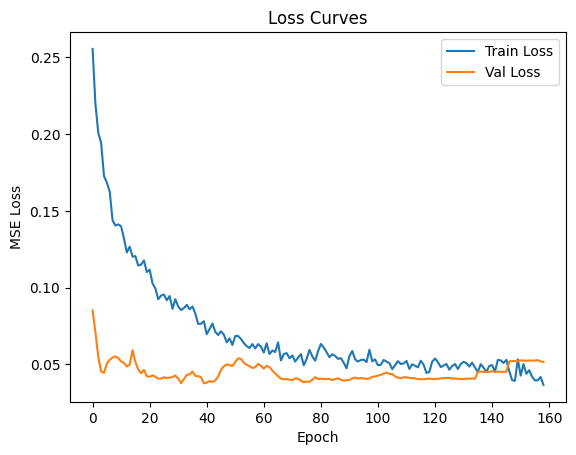

  mutant  DMS_score_predicted
0    V1D             0.538049
1    V1Y             0.275241
2    V1C             0.276511
3    V1A             0.510587
4    V1E             0.463206
5    V1W             0.129014
6    V1T             0.495061
7    V1R             0.311410
8    V1Q             0.520041
9    V1S             0.588673
      mutant                                           sequence  \
8994   L533Q  MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...   
9006   R534P  MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...   
10375  T606Q  MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...   
10104  I591A  MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...   
10781  L627E  MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...   
9017   R534A  MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...   
10789  L627P  MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...   
2068   T114A  MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...   
7375   K448A  MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...   


In [27]:
# ================= Active learning workflow =================

# Round 0: initial training on provided train.csv
df_pred, preds_per_fold, train_losses, val_losses, best_val_spearman = train_and_predict(
    df_train_current=df_train_current,
    df_test=df_test,
    device=device,
    seed=seed,
    n_splits=5,
)

import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title('Loss Curves')
plt.ylabel('MSE Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

print(df_pred[['mutant', 'DMS_score_predicted']].head(10))

df_pred[['mutant', 'DMS_score_predicted']].to_csv('predictions.csv', index=False)

df_top_ten = df_pred.sort_values('DMS_score_predicted', ascending=False).head(10)
df_top_ten.to_csv('top10.txt', columns=['mutant'], index=False, header=False)
print(df_top_ten)

# Write next query.txt
queries = select_query_mutants(
    df_test=df_test,
    queried_mutants=queried_mutants,
    preds_per_fold=preds_per_fold,
    n_query=max_queries_per_round,
    random_state=seed,
)

with open('query.txt', 'w') as f:
    for mutant in queries:
        f.write(mutant + '\n')

queried_mutants.update(queries)
print(f"Wrote {len(queries)} mutants to query.txt")

In [15]:
# Show current ESM-based predictions.
df_pred[['mutant', 'DMS_score_predicted']].head(n=10)

,mutant,DMS_score_predicted
0,V1D,0.406410
1,V1Y,0.207229
2,V1C,0.233184
3,V1A,0.518615
4,V1E,0.337954
5,V1W,0.124425
6,V1T,0.418765
7,V1R,0.311519
8,V1Q,0.491988
9,V1S,0.530722


In [16]:
# Save predictions to .csv.
df_pred[['mutant', 'DMS_score_predicted']].to_csv('test_predictions.csv', index=False)

In [17]:
# Show prediction distribution.
df_pred.sort_values('DMS_score_predicted', ascending=False)

,mutant,sequence,DMS_score_predicted
10104,I591A,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.692319
10375,T606Q,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.684131
8994,L533Q,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.678712
7959,I478L,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.675575
8412,S502P,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.672686
...,...,...,...
3331,C192P,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.004424
3902,E231F,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,0.000582
3791,D222I,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,-0.000425
3913,E231W,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...,-0.001396
